# Weather Data Analysis using Open-Meteo API

## Objective

The goal of this project is to:

- Fetch historical weather data using the Open-Meteo API.
- Clean and inspect the retrieved data.
- Perform Exploratory Data Analysis (EDA).
- Discover patterns and insights from temperature and precipitation.


In [27]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=31.2001"
    "&longitude=29.9187"
    "&start_date=2024-01-01"
    "&end_date=2024-12-31"
    "&daily=temperature_2m_mean,precipitation_sum"
    "&timezone=Africa/Cairo"
)

response = requests.get(url)

print(response.status_code)

200


In [29]:
data = response.json()

print(data)

{'latitude': 31.177504, 'longitude': 29.964329, 'generationtime_ms': 4.779458045959473, 'utc_offset_seconds': 10800, 'timezone': 'Africa/Cairo', 'timezone_abbreviation': 'GMT+3', 'elevation': 12.0, 'daily_units': {'time': 'iso8601', 'temperature_2m_mean': '°C', 'precipitation_sum': 'mm'}, 'daily': {'time': ['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-12', '2024-01-13', '2024-01-14', '2024-01-15', '2024-01-16', '2024-01-17', '2024-01-18', '2024-01-19', '2024-01-20', '2024-01-21', '2024-01-22', '2024-01-23', '2024-01-24', '2024-01-25', '2024-01-26', '2024-01-27', '2024-01-28', '2024-01-29', '2024-01-30', '2024-01-31', '2024-02-01', '2024-02-02', '2024-02-03', '2024-02-04', '2024-02-05', '2024-02-06', '2024-02-07', '2024-02-08', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12', '2024-02-13', '2024-02-14', '2024-02-15', '2024-02-16', '2024-02-17', '2024-02-18', '2024

In [30]:
daily_data = data["daily"]

df = pd.DataFrame(daily_data)

df.head(10)

,time,temperature_2m_mean,precipitation_sum
0,2024-01-01,15.8,2.3
1,2024-01-02,18.1,0.7
2,2024-01-03,17.4,0.0
3,2024-01-04,15.9,0.0
4,2024-01-05,16.6,0.0
5,2024-01-06,16.6,0.0
6,2024-01-07,16.6,0.0
7,2024-01-08,16.0,0.0
8,2024-01-09,15.1,0.0
9,2024-01-10,15.6,1.0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   time                 366 non-null    object 
 1   temperature_2m_mean  366 non-null    float64
 2   precipitation_sum    366 non-null    float64
dtypes: float64(2), object(1)
memory usage: 8.7+ KB


In [32]:
df.describe()

,temperature_2m_mean,precipitation_sum
count,366.000000,366.000000
mean,21.797268,0.461749
std,5.253721,1.571880
min,11.000000,0.000000
25%,16.625000,0.000000
50%,21.100000,0.000000
75%,27.375000,0.000000
max,31.300000,15.000000


In [34]:
df.isnull().sum()

time                   0
temperature_2m_mean    0
precipitation_sum      0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.to_csv("alexandria_weather_2024_cleaned.csv", index=False)

In [33]:
df["time"] = pd.to_datetime(df["time"])

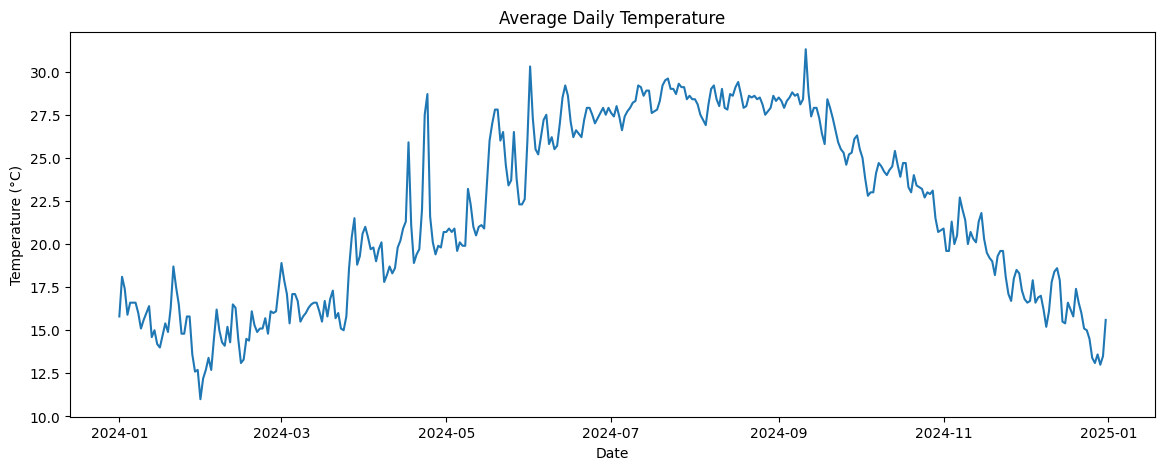

In [10]:
plt.figure(figsize=(14,5))

plt.plot(df["time"], df["temperature_2m_mean"])

plt.title("Average Daily Temperature")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.show()

Insights

- Temperature gradually increases from winter to summer.
- Highest temperatures occur during July and August.
- Lowest temperatures occur during January.
- Seasonal variation is clearly visible.

In [11]:
df["time"] = pd.to_datetime(df["time"])

df["month"] = df["time"].dt.month

df.head()

,time,temperature_2m_mean,precipitation_sum,month
0,2024-01-01,15.8,2.3,1
1,2024-01-02,18.1,0.7,1
2,2024-01-03,17.4,0.0,1
3,2024-01-04,15.9,0.0,1
4,2024-01-05,16.6,0.0,1


In [12]:
monthly_temp = df.groupby("month")["temperature_2m_mean"].mean()

monthly_temp

month
1     15.451613
2     14.824138
3     17.048387
4     20.606667
5     22.980645
6     27.130000
7     28.403226
8     28.277419
9     27.376667
10    23.600000
11    19.696667
12    15.967742
Name: temperature_2m_mean, dtype: float64

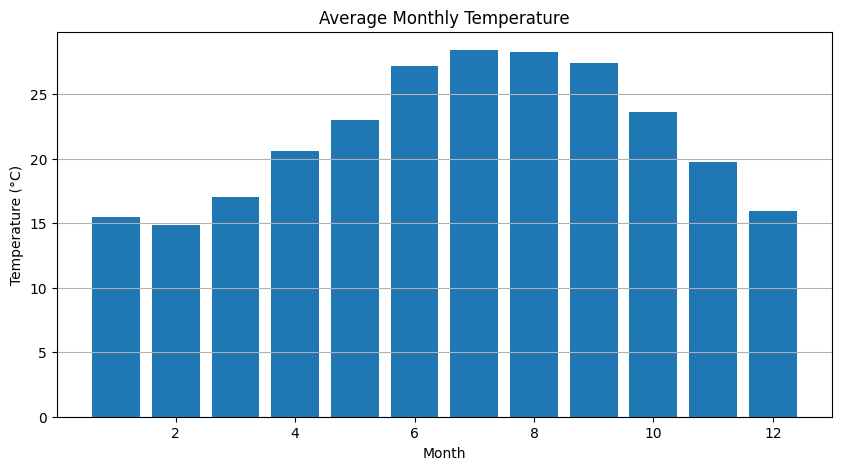

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(monthly_temp.index,
        monthly_temp.values)

plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(axis="y")

plt.show()

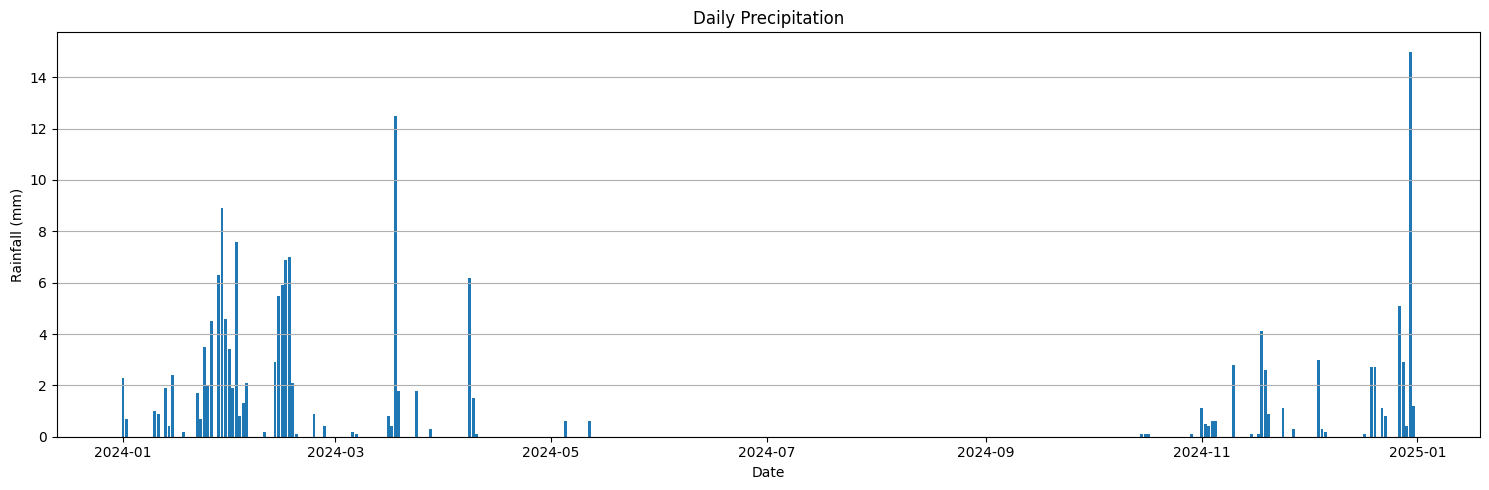

In [36]:
plt.figure(figsize=(15,5))

plt.bar(df["time"], df["precipitation_sum"])

plt.title("Daily Precipitation")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")

plt.grid(axis="y")


plt.tight_layout()

plt.show()

Insights

- Most days recorded no rainfall.
- Heavy rainfall events are rare.
- Rainfall is concentrated during winter months.

In [ ]:
monthly_rain = df.groupby("month")["precipitation_sum"].sum()

monthly_rain

month
1     45.4
2     45.6
3     17.9
4      7.8
5      1.2
6      0.0
7      0.0
8      0.0
9      0.0
10     0.4
11    15.2
12    35.5
Name: precipitation_sum, dtype: float64

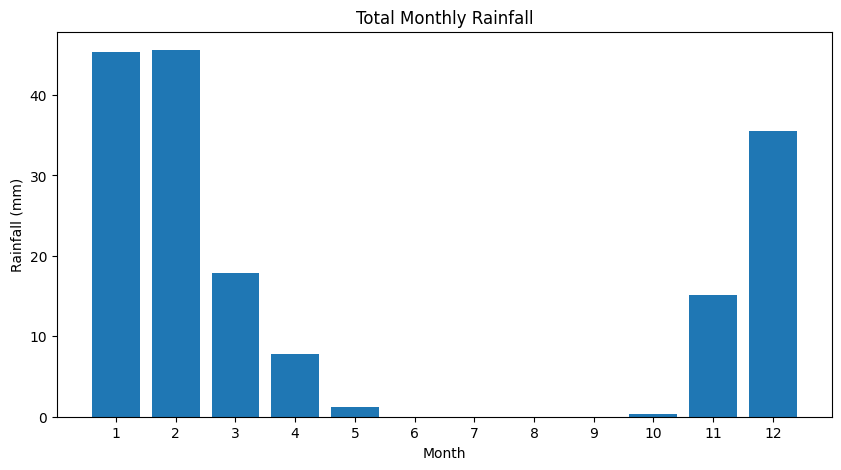

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(monthly_rain.index,monthly_rain.values)
plt.title("Total Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.xticks(range(1,13))

plt.show()

The monthly rainfall analysis indicates that precipitation is mainly concentrated during the winter season. January, February, November, and December recorded the highest rainfall amounts, while rainfall during the summer months was almost nonexistent. This pattern is consistent with the Mediterranean climate of Alexandria, where winters are relatively wet and summers are generally dry.

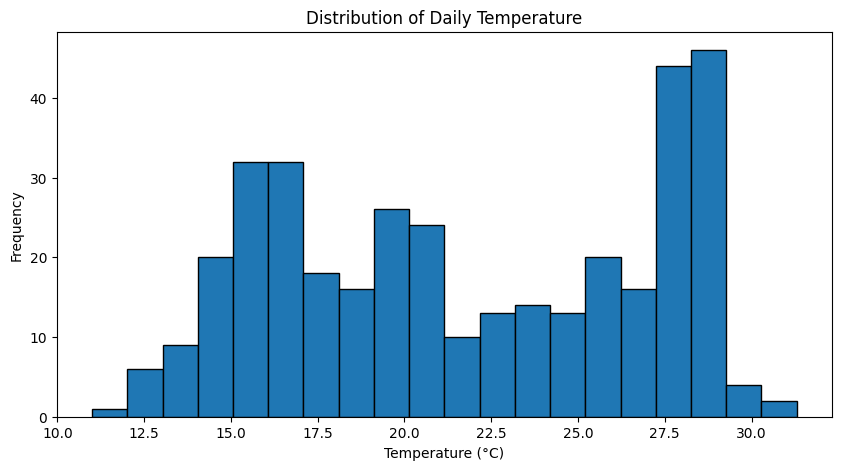

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df["temperature_2m_mean"],
         bins=20,
         edgecolor="black")

plt.title("Distribution of Daily Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

The histogram shows that daily temperatures range approximately between 11°C and 31°C, with most observations concentrated between 15°C and 29°C. The distribution reflects the seasonal variation throughout the year, where lower temperatures occur during winter and higher temperatures occur during summer. No unusual or extreme temperature values were observed, indicating that the dataset is consistent and free from significant anomalies.

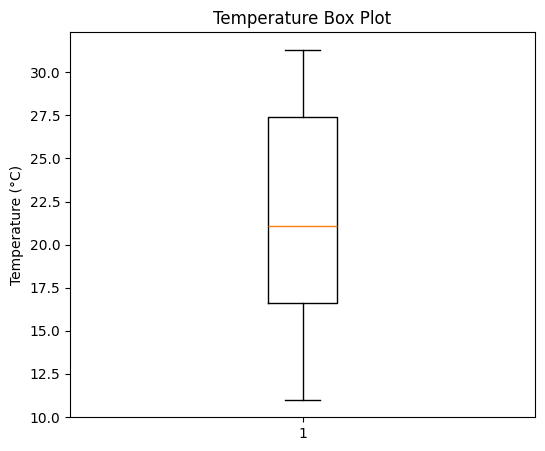

In [20]:
plt.figure(figsize=(6,5))

plt.boxplot(df["temperature_2m_mean"])

plt.title("Temperature Box Plot")
plt.ylabel("Temperature (°C)")

plt.show()

Insights

- Median temperature is around 21°C.
- No significant outliers are observed.
- Temperature values show moderate variability.

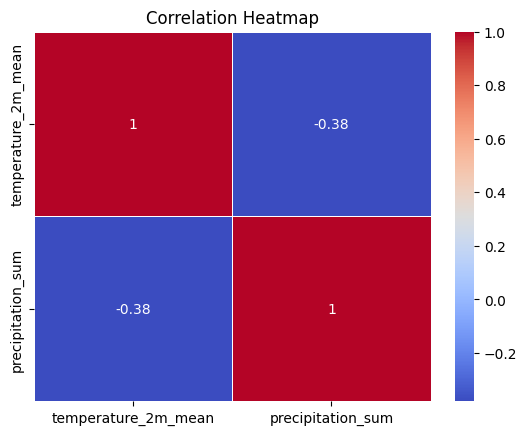

In [21]:

corr = df[["temperature_2m_mean","precipitation_sum"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

Insights

- Temperature and precipitation have a weak negative correlation.
- No strong linear relationships exist among variables.

For this project, I collected daily weather data for Alexandria, Egypt, covering the period from January 1, 2024, to December 31, 2024. The data was obtained using the Open-Meteo API because it is free, easy to access, provides historical weather information, and returns data in JSON format that can be easily processed using Python.

The exploratory analysis revealed clear seasonal patterns. Daily temperatures gradually increased from winter to summer, reaching their highest values during July and August before decreasing again toward the end of the year. Rainfall was highly seasonal, with most precipitation occurring during the winter months, while summer months experienced almost no rainfall.

The temperature series is not stationary because its mean changes over time due to seasonal effects. Similarly, precipitation also exhibits seasonal behavior, with rainfall concentrated in specific months rather than being evenly distributed throughout the year.

Regarding data quality, no missing values or duplicate records were found after collecting the data. The dataset required only minor preparation, including converting the API response into a structured DataFrame, checking data types, and formatting the date column for time-series analysis. Since no significant data quality issues were detected, no additional cleaning techniques such as imputation or duplicate removal were necessary.

Overall, the collected dataset was clean, reliable, and suitable for exploratory data analysis, providing meaningful insights into the annual weather patterns in Alexandria.